# Track A — Active SINDy Dynamics + Iterative RL Controller

SINDy dynamics and a control policy **co-improve** in an iterative active learning loop:

```
Bootstrap data  ──►  Fit SINDy  ──►  Train policy in surrogate (imagination)
                                              │
                                    Execute policy in real MuJoCo sim
                                    + collect near-equilibrium data
                                              │
                                    Refit SINDy on expanded dataset
                                              └──► repeat until convergence
```

**Key motivation:** random-policy episodes terminate in ~10 steps and never reach
the near-equilibrium region that SINDy must model accurately. A trained policy
generates exactly the trajectories SINDy benefits from most.

## Algorithm Choice: DreamerV3-style Imagination

The iterative loop maps exactly onto the DreamerV3 paradigm:

| DreamerV3 concept | This notebook |
|---|---|
| RSSM (recurrent world model) | SINDy surrogate (explicit sparse model) |
| Policy training via imagined rollouts | PPO inside `SINDySurrogateEnv` |
| World model update from real env | SINDy refit on expanded dataset |
| Real-env interaction | Controller rollout in MuJoCo |

SINDy replaces the RSSM with an **interpretable** sparse dynamics model.
At each iteration the policy "dreams" entirely inside the surrogate — no additional
real-simulator calls during PPO training.

In [1]:
# uv add stable-baselines3   (if not already in pyproject.toml)
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import pathlib

from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# Derive timestep from environment once
_env = gym.make("InvertedDoublePendulum-v5")
DT   = _env.unwrapped.dt
_env.close()

STATE_DIM  = 6
ACTION_DIM = 1
STATE_HIGH = np.array([5.0, np.pi, np.pi, 20.0, 20.0, 20.0], dtype=np.float64)
SINDY_DEG  = 2
SINDY_THRS = 0.001

L1, L2 = 0.6, 0.6  # pole lengths (m) — from MuJoCo inverted_double_pendulum.xml
TIP_HEIGHT_FALL_THRESHOLD = 1.0
TIP_HEIGHT_PROBE_MIN = 1.05
TIP_HEIGHT_TARGET = 2.0
HEALTHY_REWARD = 10.0

# Iteration-0 bootstrap budget. Each one-step probe counts as one real MuJoCo
# interaction, same as one transition collected during a rollout.
TARGET_PROBE_TRANSITIONS = 40_000
TARGET_BOOTSTRAP_TRANSITIONS = 8_000
TARGET_RANDOM_TRANSITIONS = 2_000
N_ACTIVE    = 100    # episodes to collect with trained controller per iteration
PPO_STEPS   = 50_000
MAX_ITER    = 6      # active learning iterations

DATA_DIR  = pathlib.Path("../data")
MODEL_DIR = pathlib.Path("../results/trackA")
DATA_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR.mkdir(exist_ok=True, parents=True)

# New cache name so the probing bootstrap is not skipped by an older baseline file.
BOOTSTRAP_PATH = DATA_DIR / "trajectories_trackA_probe_bootstrap.npz"
STATE_LABELS   = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]

print(f"DT = {DT:.4f} s  ({1/DT:.0f} Hz)")


DT = 0.0500 s  (20 Hz)


In [2]:
def obs_to_state6(obs):
    """9-dim MuJoCo observation → 6-dim state [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂].

    Angles recovered from sin/cos pairs via arctan2 (handles all quadrants).
    Velocities are taken directly from obs[5:8] (already clipped ±10 by MuJoCo).
    obs[8] (constraint force) is dropped — not part of the dynamics state.
    """
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),   # θ₁ = arctan2(sin θ₁, cos θ₁)
        np.arctan2(obs[2], obs[4]),   # θ₂ = arctan2(sin θ₂, cos θ₂)
        obs[5],
        obs[6],
        obs[7],
    ])

## Iteration 0: Bootstrap Data Collection

In [3]:
def balance_policy(obs, noise_std=0.1):
    """Simple PD balance heuristic for near-equilibrium bootstrap data.

    Applies a corrective force opposing the lean of both poles.
    Added Gaussian noise diversifies the state coverage.
    """
    u = (-0.5 * obs[0]       # cart position
         - 3.0 * obs[1]      # sin(θ₁) ≈ θ₁ near upright
         - 1.0 * obs[2]      # sin(θ₂) ≈ θ₂ near upright
         - 0.5 * obs[5]      # ẋ damping
         - 0.5 * obs[6]      # θ̇₁ damping
         - 0.2 * obs[7])     # θ̇₂ damping
    u += np.random.normal(0, noise_std)
    return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)


def random_policy(obs):
    return np.random.uniform(-1.0, 1.0, size=(1,)).astype(np.float32)


def tip_height_from_state6(s):
    """MuJoCo vertical tip height from [x, θ1, θ2, xdot, θ1dot, θ2dot].

    Gymnasium stores this as the z-coordinate of the tip site. In this 2D
    notebook we call it tip_height to avoid confusing planar y with MuJoCo z.
    There is no +0.8 offset here.
    """
    th1, th2 = s[1], s[2]
    return L1 * np.cos(th1) + L2 * np.cos(th1 + th2)


def sample_near_upright_state(rng):
    """Sample useful local dynamics states instead of waiting for rollouts to visit them.

    The mixture intentionally over-samples the controllable near-upright region while
    still including wider angles/velocities so SINDy sees curvature and action effects.
    """
    if rng.random() < 0.80:
        x = rng.uniform(-0.75, 0.75)
        th1 = rng.uniform(-0.30, 0.30)
        th2 = rng.uniform(-0.30, 0.30)
        xdot = rng.uniform(-2.5, 2.5)
        th1dot = rng.uniform(-3.0, 3.0)
        th2dot = rng.uniform(-3.0, 3.0)
    else:
        x = rng.uniform(-1.50, 1.50)
        th1 = rng.uniform(-0.70, 0.70)
        th2 = rng.uniform(-0.70, 0.70)
        xdot = rng.uniform(-5.0, 5.0)
        th1dot = rng.uniform(-6.0, 6.0)
        th2dot = rng.uniform(-6.0, 6.0)

    return np.array([x, th1, th2, xdot, th1dot, th2dot], dtype=np.float64)


def sample_probe_action(rng, s):
    """Mix random, saturated, and weak stabilizing actions for better input coverage."""
    mode = rng.random()
    if mode < 0.70:
        u = rng.uniform(-1.0, 1.0)
    elif mode < 0.85:
        u = rng.choice([-1.0, 1.0])
    else:
        u = (-0.4 * s[0] - 2.5 * s[1] - 1.0 * s[2]
             - 0.3 * s[3] - 0.4 * s[4] - 0.2 * s[5]
             + rng.normal(0.0, 0.15))
    return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)


def collect_state_action_probes(target_transitions, seed=0, label=""):
    """Collect one-step MuJoCo transitions from sampled near-upright states.

    This is better experimental design than pure random rollouts: random rollouts fall
    quickly and over-represent failure states, while probes directly cover the state and
    action region the learned controller needs. Each probe is still one real simulator
    interaction and is counted exactly like a rollout transition.
    """
    env = gym.make("InvertedDoublePendulum-v5")
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    X, U, X_next = [], [], []
    attempts = 0

    while len(X) < target_transitions:
        s = sample_near_upright_state(rng)
        attempts += 1

        # Keep probes in the physically relevant upright basin. This rejects wide-angle
        # samples whose tip has already fallen below the real environment's failure band.
        if tip_height_from_state6(s) <= TIP_HEIGHT_PROBE_MIN:
            continue

        a = sample_probe_action(rng, s)
        env.unwrapped.set_state(s[:3], s[3:])
        nobs, _, term, trunc, _ = env.step(a)
        ns = obs_to_state6(nobs)

        if np.all(np.isfinite(ns)):
            X.append(s)
            U.append(a.astype(np.float64))
            X_next.append(ns)

    env.close()
    X = np.asarray(X)
    U = np.asarray(U)
    X_next = np.asarray(X_next)
    if label:
        reject_rate = 1.0 - len(X) / max(attempts, 1)
        print(f"[{label}] collected {len(X):,} one-step probes"
              f" | rejected {reject_rate:.1%} sampled states")
    return X, U, X_next


def collect_until(policy_fn, target_transitions, seed=0, label=""):
    chunks = []
    total = 0
    episode_seed = seed
    while total < target_transitions:
        X, U, X_next = collect_episodes(1, policy_fn, seed=episode_seed)
        chunks.append((X, U, X_next))
        total += len(X)
        episode_seed += 1

    X = np.vstack([c[0] for c in chunks])[:target_transitions]
    U = np.vstack([c[1] for c in chunks])[:target_transitions]
    X_next = np.vstack([c[2] for c in chunks])[:target_transitions]
    if label:
        print(f"[{label}] collected {len(X):,} transitions")
    return X, U, X_next


def collect_episodes(n_episodes, policy_fn, seed=0, label=""):
    """Collect (X, U, X_next) transitions using policy_fn(obs) -> action."""
    env = gym.make("InvertedDoublePendulum-v5")
    rng = np.random.default_rng(seed)
    X, U, X_next, lengths = [], [], [], []

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        s      = obs_to_state6(obs)
        done   = False
        ep_len = 0

        while not done:
            a    = policy_fn(obs)
            nobs, _, term, trunc, _ = env.step(a)
            done = term or trunc
            ns   = obs_to_state6(nobs)
            X.append(s)
            U.append(a.astype(np.float64))
            X_next.append(ns)
            s = ns
            obs = nobs
            ep_len += 1

        lengths.append(ep_len)

    env.close()
    if label:
        print(f"  [{label}] {n_episodes} eps | {len(X):,} transitions"
              f" | median length {np.median(lengths):.0f} steps")
    return np.array(X), np.array(U), np.array(X_next)


In [4]:
if BOOTSTRAP_PATH.exists():
    d = np.load(BOOTSTRAP_PATH)
    X_all, U_all, Xn_all = d["X"], d["U"], d["X_next"]
    print(f"Loaded probing bootstrap data ({X_all.shape[0]:,} transitions)")
else:
    print("Collecting bootstrap data (near-upright probes + balance/random rollouts) …")
    X_probe, U_probe, Xn_probe = collect_state_action_probes(
        TARGET_PROBE_TRANSITIONS, seed=0, label="iter-0 near-upright probes"
    )
    X_bal, U_bal, Xn_bal = collect_until(
        balance_policy, TARGET_BOOTSTRAP_TRANSITIONS, seed=10_000, label="iter-0 balance rollout"
    )
    X_r, U_r, Xn_r = collect_until(
        random_policy, TARGET_RANDOM_TRANSITIONS, seed=20_000, label="iter-0 random rollout"
    )
    X_all  = np.vstack([X_probe,  X_bal,  X_r])
    U_all  = np.vstack([U_probe,  U_bal,  U_r])
    Xn_all = np.vstack([Xn_probe, Xn_bal, Xn_r])
    np.savez(BOOTSTRAP_PATH, X=X_all, U=U_all, X_next=Xn_all)
    print(f"Bootstrap dataset: {X_all.shape[0]:,} transitions saved to {BOOTSTRAP_PATH}")


[iter-0 near-upright probes] collected 40,000 one-step probes | rejected 6.6% sampled states
[iter-0 balance rollout] collected 8,000 transitions
[iter-0 random rollout] collected 2,000 transitions
Bootstrap dataset: 50,000 transitions saved to ../data/trajectories_trackA_probe_bootstrap.npz


## Fit Initial SINDy Model (Iteration 0)

In [5]:
def fit_sindy(X, U, X_next, degree=SINDY_DEG, threshold=SINDY_THRS):
    """Fit discrete-time SINDyC surrogate: delta_x = f(x_k, u_k).

    Returns the fitted model and a held-out one-step RMSE.
    """
    n = len(X)
    rng = np.random.default_rng(7)
    idx = rng.permutation(n)
    n_test = max(1, n // 5)
    te = idx[:n_test]
    tr = idx[n_test:]

    Y_delta = X_next - X

    model = ps.SINDy(
        feature_library=ps.PolynomialLibrary(degree=degree),
        optimizer=ps.optimizers.STLSQ(threshold=threshold, alpha=0.01),
    )

    model.fit(x=X[tr], t=1, u=U[tr], x_dot=Y_delta[tr])

    delta_pred = model.predict(X[te], u=U[te])
    Xn_pred = X[te] + delta_pred

    rmse = float(np.sqrt(np.mean((Xn_pred - X_next[te]) ** 2)))
    return model, rmse

sindy_models = {}
rmse_history = {}

sindy_models[0], rmse_history[0] = fit_sindy(X_all, U_all, Xn_all)
print(f"Iteration 0  |  transitions: {X_all.shape[0]:,}  |  one-step RMSE: {rmse_history[0]:.6f}")





Iteration 0  |  transitions: 50,000  |  one-step RMSE: 1.053028


## SINDy Surrogate Environment

> **Coordination note (Track A & B):** Both tracks need `SINDySurrogateEnv`.
> The interface spec here matches Track B's wrapper exactly.
> Once both tracks are running, consolidate into `sindy_rl/envs/sindy_env.py`
> and import from there.

In [6]:
L1, L2 = 0.6, 0.6  # pole lengths (m) from MuJoCo inverted_double_pendulum.xml
TIP_HEIGHT_FALL_THRESHOLD = 1.0
TIP_HEIGHT_TARGET = 2.0
HEALTHY_REWARD = 10.0

class SINDySurrogateEnv(gym.Env):
    """Gymnasium env backed by a fitted PySINDy model.

    State is the 6D SINDy state:
        [x, theta1, theta2, xdot, theta1dot, theta2dot]

    Action is the normalized MuJoCo cart force in [-1, 1].

    Reward/termination mirror Gymnasium's InvertedDoublePendulum-v5 geometry:
        x_tip      = x + L1*sin(theta1) + L2*sin(theta1 + theta2)
        tip_height = L1*cos(theta1) + L2*cos(theta1 + theta2)
        reward     = 10 - 0.01*x_tip^2 - (tip_height - 2)^2 - velocity_penalty

    MuJoCo calls vertical height z because its world is 3D. This notebook uses
    tip_height as the variable name so the 2D geometry remains readable.
    """
    metadata = {"render_modes": []}

    def __init__(self, sindy_model, initial_states, dt=DT, max_steps=1000):
        super().__init__()
        self.sindy_model    = sindy_model
        self.initial_states = np.asarray(initial_states)
        self.dt             = dt
        self.max_steps      = max_steps
        self.observation_space = spaces.Box(
            low=-STATE_HIGH,
            high=STATE_HIGH,
            shape=(STATE_DIM,),
            dtype=np.float64,
        )
        self.action_space = spaces.Box(-1.0, 1.0, shape=(1,), dtype=np.float32)
        self._s = None
        self._n = 0

    @staticmethod
    def _state_to_obs(s):
        x, th1, th2, xdot, th1dot, th2dot = s
        return np.array([
            x,
            np.sin(th1), np.sin(th2),
            np.cos(th1), np.cos(th2),
            np.clip(xdot,   -10.0, 10.0),
            np.clip(th1dot, -10.0, 10.0),
            np.clip(th2dot, -10.0, 10.0),
            0.0,   # constraint force is not modeled by SINDy
        ], dtype=np.float64)

    def _tip_position(self):
        x, th1, th2 = self._s[0], self._s[1], self._s[2]
        x_tip = x + L1 * np.sin(th1) + L2 * np.sin(th1 + th2)
        tip_height = L1 * np.cos(th1) + L2 * np.cos(th1 + th2)
        return x_tip, tip_height

    def _reward(self, terminated: bool) -> float:
        _, _, _, _, th1dot, th2dot = self._s
        x_tip, tip_height = self._tip_position()
        dist_penalty = 0.01 * x_tip**2 + (tip_height - TIP_HEIGHT_TARGET) ** 2
        vel_penalty = (
            1e-3 * np.clip(th1dot, -10.0, 10.0) ** 2
            + 5e-3 * np.clip(th2dot, -10.0, 10.0) ** 2
        )
        alive_bonus = HEALTHY_REWARD * int(not terminated)
        return float(alive_bonus - dist_penalty - vel_penalty)

    def _terminated(self):
        if not np.all(np.isfinite(self._s)):
            return True
        if np.any(np.abs(self._s) > STATE_HIGH):
            return True
        _, tip_height = self._tip_position()
        return bool(tip_height <= TIP_HEIGHT_FALL_THRESHOLD)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        idx      = self.np_random.integers(0, len(self.initial_states))
        self._s  = self.initial_states[idx].copy()
        self._s += self.np_random.normal(0.0, 0.01, STATE_DIM)
        self._n  = 0
        return self._s.copy(), {}

    def step(self, action):
        a = np.clip(np.asarray(action, dtype=np.float64).reshape(1), -1.0, 1.0)
        delta = self.sindy_model.predict(self._s.reshape(1, -1), u=a.reshape(1, -1))[0]
        self._s = self._s + delta
        terminated = self._terminated()
        reward = self._reward(terminated)
        self._n += 1
        truncated = self._n >= self.max_steps
        return self._s.copy(), reward, terminated, truncated, {}

    def render(self):
        pass


In [7]:
# Optional geometry validation against Gymnasium/MuJoCo.
# Keep this near the surrogate environment so reward bugs fail fast.
TIP_HEIGHT_FALL_THRESHOLD = 1.0
TIP_HEIGHT_TARGET = 2.0
HEALTHY_REWARD = 10.0


def tip_position_from_state6(s):
    """Return (x_tip, tip_height) for the MuJoCo tip site.

    MuJoCo stores vertical height in data.site_xpos[..., 2]. We name the value
    tip_height in the notebook because the mechanism is drawn in a 2D x/height
    plane, where calling the vertical coordinate y would also be natural.
    """
    x, theta1, theta2 = s[0], s[1], s[2]
    x_tip = x + L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    tip_height = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    return float(x_tip), float(tip_height)


def reward_done_from_state6(s):
    """Gymnasium reward/termination formula evaluated from the 6D SINDy state."""
    x_tip, tip_height = tip_position_from_state6(s)
    terminated = bool(tip_height <= TIP_HEIGHT_FALL_THRESHOLD)
    dist_penalty = 0.01 * x_tip**2 + (tip_height - TIP_HEIGHT_TARGET) ** 2
    vel_penalty = 1e-3 * s[4] ** 2 + 5e-3 * s[5] ** 2
    reward = HEALTHY_REWARD * int(not terminated) - dist_penalty - vel_penalty
    return float(reward), terminated


def validate_tip_geometry(n=64, seed=123):
    """Check the notebook geometry against MuJoCo's actual tip site and reward."""
    env = gym.make("InvertedDoublePendulum-v5")
    rng = np.random.default_rng(seed)
    max_site_error = 0.0
    max_reward_error = 0.0

    for _ in range(n):
        env.reset(seed=int(rng.integers(0, 2**31)))
        s = np.array([
            rng.uniform(-1.0, 1.0),
            rng.uniform(-0.7, 0.7),
            rng.uniform(-0.7, 0.7),
            rng.uniform(-3.0, 3.0),
            rng.uniform(-4.0, 4.0),
            rng.uniform(-4.0, 4.0),
        ], dtype=np.float64)
        env.unwrapped.set_state(s[:3], s[3:])

        mujoco_x, _, mujoco_tip_height = env.unwrapped.data.site_xpos[0]
        formula_x, formula_tip_height = tip_position_from_state6(s)
        max_site_error = max(
            max_site_error,
            abs(formula_x - mujoco_x),
            abs(formula_tip_height - mujoco_tip_height),
        )

        terminated = bool(mujoco_tip_height <= TIP_HEIGHT_FALL_THRESHOLD)
        mujoco_reward, _ = env.unwrapped._get_rew(mujoco_x, mujoco_tip_height, terminated)
        formula_reward, formula_done = reward_done_from_state6(s)
        max_reward_error = max(max_reward_error, abs(formula_reward - mujoco_reward))
        assert formula_done == terminated

    env.close()
    assert max_site_error < 1e-10, max_site_error
    assert max_reward_error < 1e-10, max_reward_error
    print(f"Geometry/reward check passed | max site error {max_site_error:.2e} | max reward error {max_reward_error:.2e}")


validate_tip_geometry()


Geometry/reward check passed | max site error 2.22e-16 | max reward error 1.78e-15


In [8]:
from gymnasium.utils.env_checker import check_env

_test_env = SINDySurrogateEnv(sindy_models[0], X_all[:200])
check_env(_test_env)
print("env_checker: OK")

# Quick smoke test
obs, _ = _test_env.reset(seed=0)
for _ in range(10):
    obs, r, term, trunc, _ = _test_env.step(_test_env.action_space.sample())
print(f"10 random steps completed — final reward: {r:.4f}")

env_checker: OK
10 random steps completed — final reward: -2.1786


/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.12/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


## Iterative Active Learning Loop
### DreamerV3 mapping: train policy in imagination → execute in real env → update world model

Each iteration:
1. **Train PPO in SINDy surrogate** (= "dreaming" — no real-sim calls)
2. **Execute trained policy in real MuJoCo sim** (= real-env interaction)
3. **Refit SINDy on expanded dataset** (= world model update)

In [9]:
def rollout_sindy(model, x0, U_seq):
    """Roll out delta-discrete SINDy model from x0 for len(U_seq) steps."""
    x    = x0.copy()
    traj = [x]
    for u in U_seq:
        delta = model.predict(x.reshape(1, -1), u=u.reshape(1, -1))[0]
        x    = x + delta
        traj.append(x)
    return np.array(traj)


def train_ppo_in_surrogate(sindy_model, dataset, n_steps, iteration):
    """Train PPO inside SINDy surrogate. Returns the trained policy."""
    env   = Monitor(SINDySurrogateEnv(sindy_model, dataset))
    model = PPO(
        "MlpPolicy", env,
        learning_rate=3e-4, n_steps=2048,
        batch_size=64, n_epochs=10,
        gamma=0.99, ent_coef=0.01,
        verbose=0,
    )
    model.learn(total_timesteps=n_steps, progress_bar=True)
    path = str(MODEL_DIR / f"ppo_iter{iteration}")
    model.save(path)
    recent = env.get_episode_rewards()[-100:]
    print(f"  Surrogate final-100-ep mean reward: {np.mean(recent):.2f}")
    return model


def collect_with_policy(ppo_model, n_episodes, seed=0, label=""):
    """Execute trained policy in real MuJoCo sim. DreamerV3 real-env phase."""
    def policy_fn(obs):
        state = obs_to_state6(obs)
        action, _ = ppo_model.predict(state, deterministic=True)
        return action.astype(np.float32)
    return collect_episodes(n_episodes, policy_fn, seed=seed, label=label)

In [10]:
print("=" * 60)
print("Active SINDy learning loop")
print("=" * 60)

for iteration in range(1, MAX_ITER + 1):
    print(f"\n── Iteration {iteration} " + "─" * 44)

    # Step 1: Train policy inside SINDy surrogate (dreaming phase)
    print(f"  Step 1: Train PPO in SINDy[{iteration-1}] surrogate ({PPO_STEPS:,} steps)")
    ppo = train_ppo_in_surrogate(
        sindy_models[iteration - 1], X_all, PPO_STEPS, iteration
    )

    # Step 2: Collect near-equilibrium data with trained policy in real sim
    print(f"  Step 2: Execute policy in real sim — collect {N_ACTIVE} episodes")
    X_new, U_new, Xn_new = collect_with_policy(
        ppo, N_ACTIVE,
        seed=iteration * 100,
        label=f"iter-{iteration} policy rollout",
    )

    # Step 3: Expand dataset and refit SINDy (world model update)
    X_all  = np.vstack([X_all,  X_new])
    U_all  = np.vstack([U_all,  U_new])
    Xn_all = np.vstack([Xn_all, Xn_new])
    np.savez(
        DATA_DIR / f"trajectories_trackA_iter{iteration}.npz",
        X=X_all, U=U_all, X_next=Xn_all,
    )

    print(f"  Step 3: Refit SINDy on {X_all.shape[0]:,} transitions")
    sindy_models[iteration], rmse_history[iteration] = fit_sindy(X_all, U_all, Xn_all)
    print(
        f"  One-step RMSE: {rmse_history[iteration]:.6f}"
        f"  (was {rmse_history[iteration-1]:.6f},"
        f"  Δ = {rmse_history[iteration] - rmse_history[iteration-1]:+.6f})"
    )

print("\nLoop complete.")

Active SINDy learning loop

── Iteration 1 ────────────────────────────────────────────
  Step 1: Train PPO in SINDy[0] surrogate (50,000 steps)


Output()

  Surrogate final-100-ep mean reward: 2599.40
  Step 2: Execute policy in real sim — collect 100 episodes
  [iter-1 policy rollout] 100 eps | 978 transitions | median length 9 steps
  Step 3: Refit SINDy on 50,978 transitions


Output()

  One-step RMSE: 1.086655  (was 1.053028,  Δ = +0.033627)

── Iteration 2 ────────────────────────────────────────────
  Step 1: Train PPO in SINDy[1] surrogate (50,000 steps)


...

  One-step RMSE: 1.063716  (was 1.069061,  Δ = -0.005345)

── Iteration 5 ────────────────────────────────────────────
  Step 1: Train PPO in SINDy[4] surrogate (50,000 steps)


  Surrogate final-100-ep mean reward: 2231.64
  Step 2: Execute policy in real sim — collect 100 episodes
  [iter-5 policy rollout] 100 eps | 950 transitions | median length 9 steps
  Step 3: Refit SINDy on 54,789 transitions


Output()

  One-step RMSE: 1.045741  (was 1.063716,  Δ = -0.017975)

── Iteration 6 ────────────────────────────────────────────
  Step 1: Train PPO in SINDy[5] surrogate (50,000 steps)


  Surrogate final-100-ep mean reward: 2312.78
  Step 2: Execute policy in real sim — collect 100 episodes
  [iter-6 policy rollout] 100 eps | 895 transitions | median length 8 steps
  Step 3: Refit SINDy on 55,684 transitions
  One-step RMSE: 1.069847  (was 1.045741,  Δ = +0.024106)

Loop complete.


## Results: SINDy Model Improvement Over Iterations

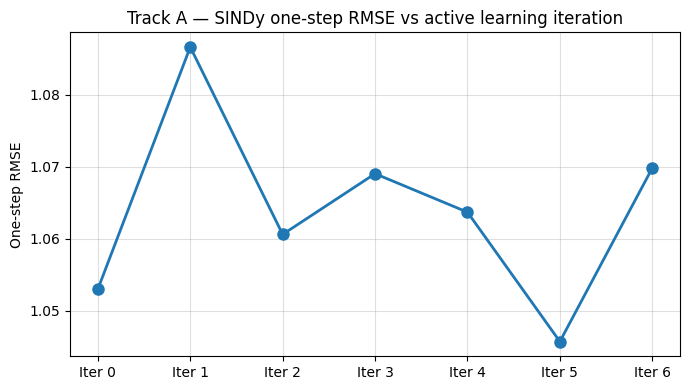

  Iter 0: RMSE = 1.053028  |  cumulative transitions ≈ 55,684
  Iter 1: RMSE = 1.086655  |  cumulative transitions ≈ 50,978
  Iter 2: RMSE = 1.060630  |  cumulative transitions ≈ 51,948
  Iter 3: RMSE = 1.069061  |  cumulative transitions ≈ 52,855
  Iter 4: RMSE = 1.063716  |  cumulative transitions ≈ 53,839
  Iter 5: RMSE = 1.045741  |  cumulative transitions ≈ 54,789
  Iter 6: RMSE = 1.069847  |  cumulative transitions ≈ 55,684


In [11]:
iters     = sorted(rmse_history.keys())
rmse_vals = [rmse_history[i] for i in iters]

plt.figure(figsize=(7, 4))
plt.plot(iters, rmse_vals, "o-", lw=2, markersize=8)
plt.xticks(iters, [f"Iter {i}" for i in iters])
plt.ylabel("One-step RMSE")
plt.title("Track A — SINDy one-step RMSE vs active learning iteration")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

for i in iters:
    n = np.load(DATA_DIR / f"trajectories_trackA_iter{i}.npz")["X"].shape[0] if i > 0 else X_all.shape[0]
    print(f"  Iter {i}: RMSE = {rmse_history[i]:.6f}  |  cumulative transitions ≈ {n:,}")

## Final Evaluation in Real Simulator

In [12]:
final_iter = max(sindy_models.keys())
final_ppo  = PPO.load(str(MODEL_DIR / f"ppo_iter{final_iter}"))

eval_env = gym.make("InvertedDoublePendulum-v5")
N_EVAL   = 20
ep_rewards_real, ep_lengths_real = [], []

for seed in range(N_EVAL):
    obs, _ = eval_env.reset(seed=seed)
    done = False
    ep_r = ep_l = 0
    while not done:
        state = obs_to_state6(obs)
        action, _ = final_ppo.predict(state, deterministic=True)
        obs, r, term, trunc, _ = eval_env.step(action)
        done = term or trunc
        ep_r += r
        ep_l += 1
    ep_rewards_real.append(ep_r)
    ep_lengths_real.append(ep_l)

eval_env.close()

mean_r  = np.mean(ep_rewards_real)
std_r   = np.std(ep_rewards_real)
mean_l  = np.mean(ep_lengths_real)
surv500 = 100 * np.mean(np.array(ep_lengths_real) > 500)
n_boot  = np.load(BOOTSTRAP_PATH)["X"].shape[0]
n_act   = X_all.shape[0] - n_boot

print("── Track A: Final evaluation (real simulator) ─────────────────────")
print(f"  Policy from iteration        : {final_iter}")
print(f"  Mean episode reward          : {mean_r:.2f} ± {std_r:.2f}")
print(f"  Mean episode duration        : {mean_l:.0f} steps")
print(f"  % surviving > 500 steps      : {surv500:.0f} %")
print(f"  Bootstrap sim interactions   : {n_boot:,}")
print(f"  Active-loop sim interactions : {n_act:,}")
print(f"  Total real sim interactions  : {X_all.shape[0]:,}")
print(f"  SINDy RMSE (final)           : {rmse_history[final_iter]:.6f}")

── Track A: Final evaluation (real simulator) ─────────────────────
  Policy from iteration        : 6
  Mean episode reward          : 78.42 ± 23.68
  Mean episode duration        : 10 steps
  % surviving > 500 steps      : 0 %
  Bootstrap sim interactions   : 50,000
  Active-loop sim interactions : 5,684
  Total real sim interactions  : 55,684
  SINDy RMSE (final)           : 1.069847
